# IELTS Performance Prediction — Exploratory Data Analysis


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs('../results', exist_ok=True)
sns.set_theme(style='whitegrid', palette='muted')
%matplotlib inline

## 1. Load Data


In [2]:
df = pd.read_csv('../data/raw/dataset.csv')
print('Shape:', df.shape)
df.head()

Shape: (5000, 10)


,Reading_Score,Writing_Score,Listening_Score,Speaking_Score,Attendance_Percentage,Practice_Hours,Vocabulary_Score,Grammar_Score,Mock_Test_Score,Final_IELTS_Band
0,5.3,4.9,5.5,5.9,100.0,2.8,66.6,52.7,6.4,5.5
1,4.5,4.5,4.8,5.1,100.0,3.2,64.2,58.1,4.3,4.7
2,4.3,5.2,5.8,5.0,100.0,5.1,63.2,57.7,6.6,5.4
3,6.6,6.9,7.5,7.3,100.0,7.5,70.3,73.8,6.8,7.2
4,5.3,5.9,4.2,3.4,100.0,6.2,35.8,53.7,5.3,4.9


In [3]:
df.describe().round(2)

,Reading_Score,Writing_Score,Listening_Score,Speaking_Score,Attendance_Percentage,Practice_Hours,Vocabulary_Score,Grammar_Score,Mock_Test_Score,Final_IELTS_Band
count,5000.00,5000.00,5000.00,5000.00,5000.0,5000.00,5000.00,5000.00,5000.00,5000.00
mean,5.00,5.02,5.02,4.99,100.0,5.00,50.34,50.62,5.00,5.01
std,1.43,1.52,1.39,1.48,0.0,2.09,17.02,17.20,1.39,1.24
min,1.00,1.00,1.00,1.00,100.0,0.50,20.00,20.00,1.00,1.00
25%,4.10,4.00,4.10,4.00,100.0,3.60,38.10,38.20,4.10,4.20
50%,5.00,5.00,5.00,5.00,100.0,5.00,49.90,50.70,5.00,5.00
75%,6.00,6.00,6.00,6.00,100.0,6.40,61.92,62.60,5.90,5.80
max,9.00,9.00,9.00,9.00,100.0,10.00,100.00,100.00,9.00,8.70


In [4]:
print('Missing values:')
print(df.isnull().sum())

Missing values:
Reading_Score            0
Writing_Score            0
Listening_Score          0
Speaking_Score           0
Attendance_Percentage    0
Practice_Hours           0
Vocabulary_Score         0
Grammar_Score            0
Mock_Test_Score          0
Final_IELTS_Band         0
dtype: int64


## 2. Target Distribution


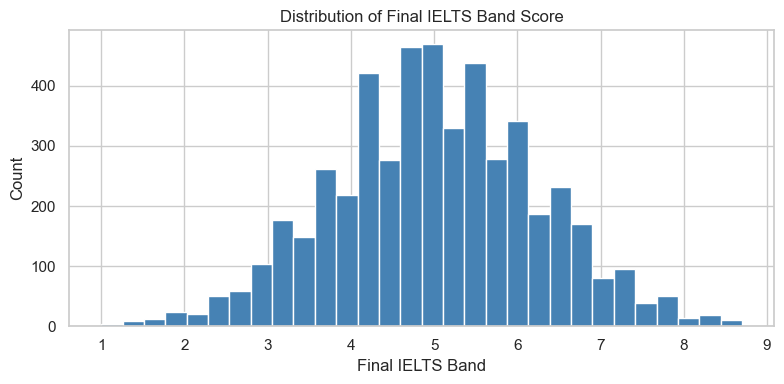

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df['Final_IELTS_Band'], bins=30, edgecolor='white', color='steelblue')
ax.set_xlabel('Final IELTS Band')
ax.set_ylabel('Count')
ax.set_title('Distribution of Final IELTS Band Score')
plt.tight_layout()
plt.savefig('../results/target_distribution.png', dpi=150)
plt.show()

## 3. Feature Distributions


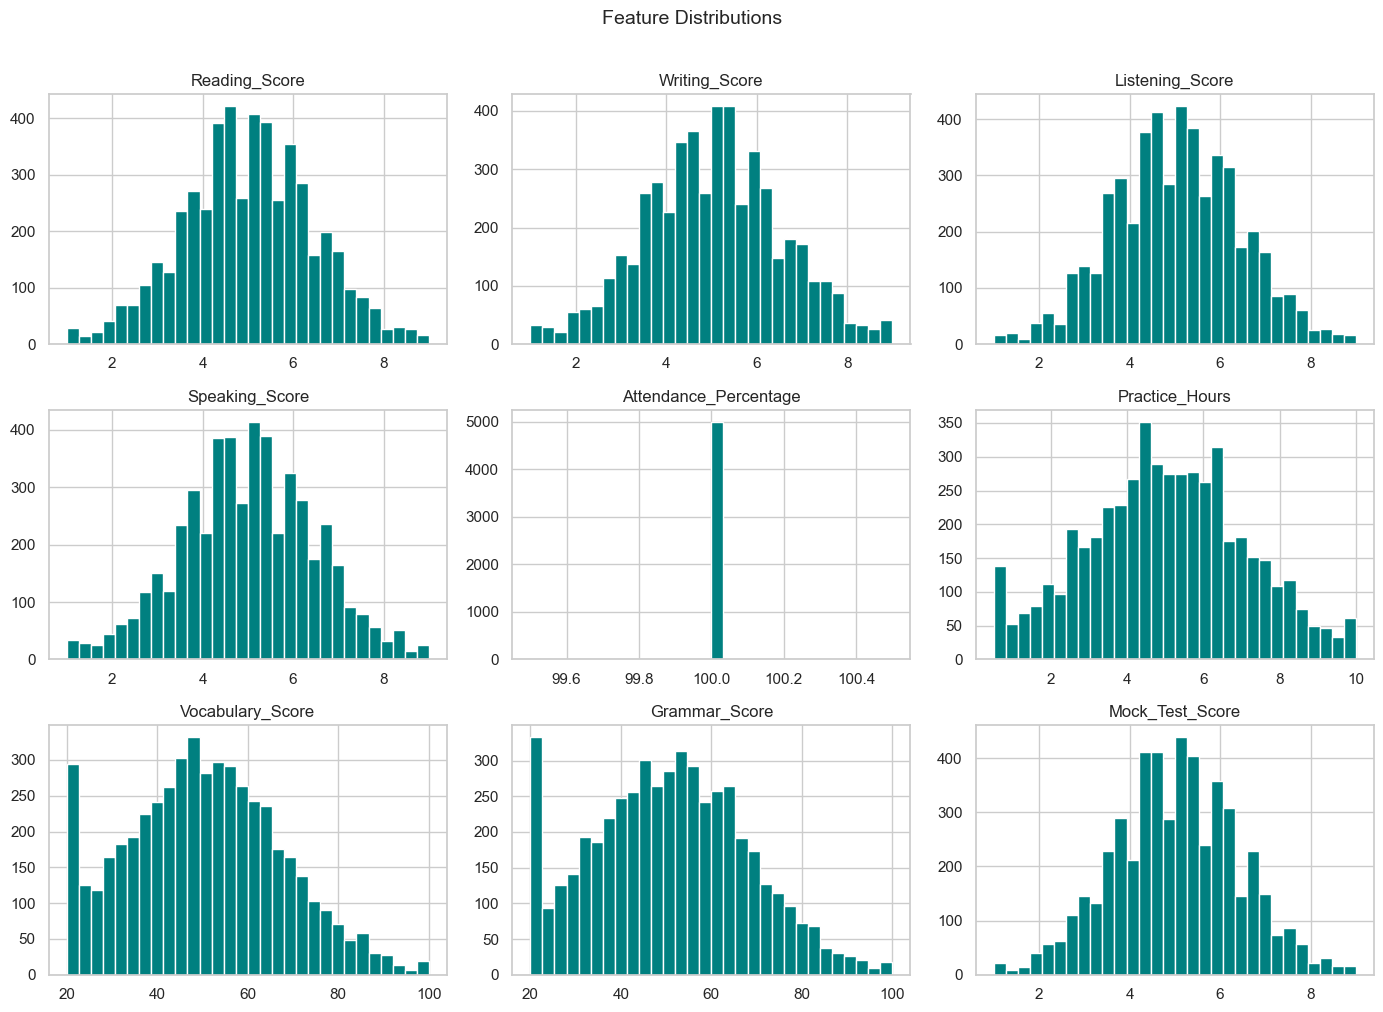

In [6]:
features = [c for c in df.columns if c != 'Final_IELTS_Band']
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()
for i, col in enumerate(features):
    axes[i].hist(df[col], bins=30, edgecolor='white', color='teal')
    axes[i].set_title(col)
    axes[i].set_xlabel('')
plt.suptitle('Feature Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../results/feature_distributions.png', dpi=150)
plt.show()

## 4. Correlation Heatmap


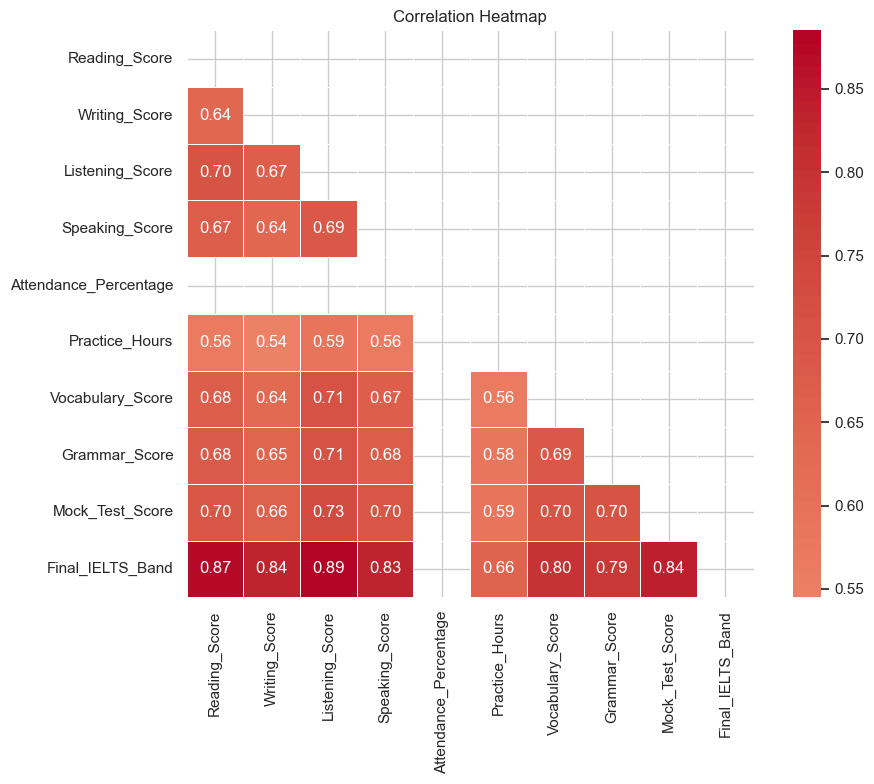

In [7]:
fig, ax = plt.subplots(figsize=(10, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, ax=ax,
    linewidths=0.5, square=True
)
ax.set_title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('../results/correlation_heatmap.png', dpi=150)
plt.show()

## 5. Feature vs Target Scatter (Top 4)


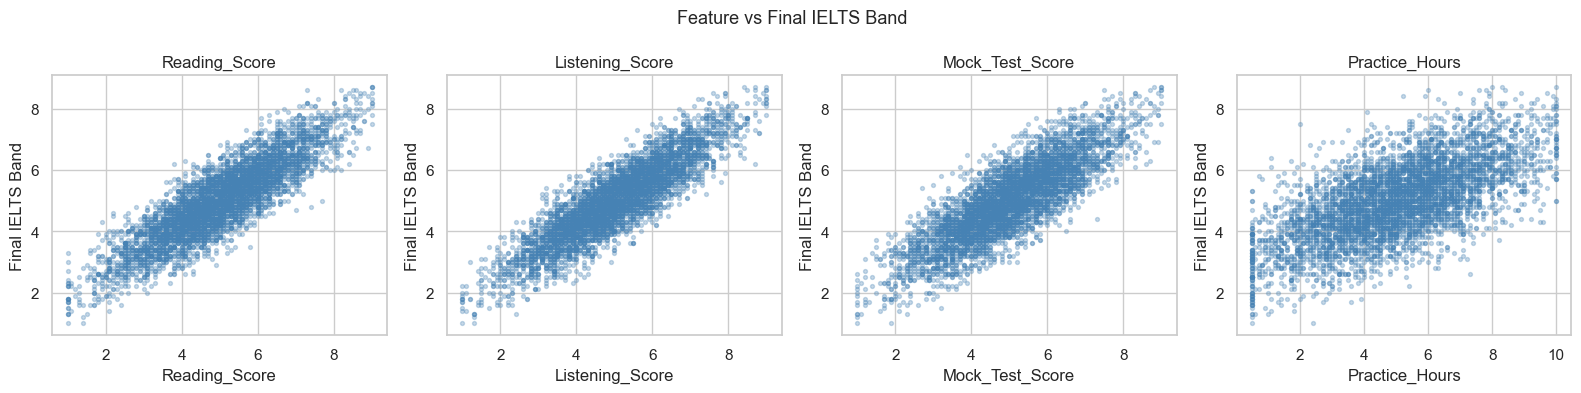

In [8]:
top_features = ['Reading_Score', 'Listening_Score', 'Mock_Test_Score', 'Practice_Hours']
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, feat in zip(axes, top_features):
    ax.scatter(df[feat], df['Final_IELTS_Band'], alpha=0.3, s=8, color='steelblue')
    ax.set_xlabel(feat)
    ax.set_ylabel('Final IELTS Band')
    ax.set_title(feat)
plt.suptitle('Feature vs Final IELTS Band', fontsize=13)
plt.tight_layout()
plt.savefig('../results/scatter_top_features.png', dpi=150)
plt.show()

## 6. Key Observations

- **Reading, Listening, and Mock Test Score** are the strongest individual predictors of Final IELTS Band.
- **Practice Hours** shows a moderate positive relationship — more practice correlates with higher band.
- **Attendance** has a weaker direct correlation but likely contributes indirectly.
- No missing values — dataset is clean and ready for modelling.
